In [176]:
import requests
import numpy as np
import json
import pandas as pd
from datetime import datetime, timedelta
import sklearn
import xgboost as xgb
import pickle

loaded_model = xgb.XGBRegressor()
loaded_model.load_model("xgb_model_SPY_0.0365_sorted.json")

In [177]:
API_KEY = "wUvM2M29ZVxHDvK8IRp2P7iyrT8uhQG4"

ticker = "AAPL"

import pandas as pd

end_date = pd.to_datetime("2023-06-01")
start_date = end_date - pd.tseries.offsets.BDay(83)

print(start_date)


url_hist_stock_price = f"https://financialmodelingprep.com/stable/historical-price-eod/full?symbol={ticker}&from={start_date.date()}&to={end_date.date()}&apikey={API_KEY}"

# Historical Data Request
response_hist_stock_price = requests.get(url_hist_stock_price)

json_response_hist_stock_price = response_hist_stock_price.json()

df_stock_hist = pd.DataFrame(json_response_hist_stock_price)

df_stock_hist['date'] = pd.to_datetime(df_stock_hist['date'])
df_stock_hist['close'] = df_stock_hist['close'].astype(float)
df_stock_hist['open'] = df_stock_hist['open'].astype(float)
df_stock_hist['high'] = df_stock_hist['high'].astype(float)
df_stock_hist['low'] = df_stock_hist['low'].astype(float)

df_stock_hist.set_index('date', inplace=True)
df_stock_hist.drop(columns=['symbol'])

closing_price = df_stock_hist[['close']]
closing_price = closing_price.sort_index(ascending=True)

# AD LINE
denominator = df_stock_hist['high'] - df_stock_hist['low']
denominator = denominator.replace(0, np.nan)

# RESEARCH A BIT MORE
mfm = ((df_stock_hist['close'] - df_stock_hist['low']) - (df_stock_hist['high'] - df_stock_hist['close'])) / denominator
mfv_series = mfm * df_stock_hist['volume']
mfv = mfv_series.fillna(0)
mfv = mfv.to_frame(name="MFV")
ad_line = mfv['MFV'].cumsum().to_frame()
ad_line = ad_line.sort_index(ascending=True)
i_volume = df_stock_hist[['volume']]
i_volume = i_volume.sort_index(ascending=True)
volume =i_volume.apply(np.log10)


2023-02-06 00:00:00


              ret_1d    ret_5d   ret_10d    vol_5d   vol_10d  momentum_10d  \
date                                                                         
2023-04-19  0.006968  0.047033  0.012075  0.015765  0.013837           2.0   

            sma_ratio_10_50  zscore_20d     rsi_14    volume  AD_momentum_5d  \
date                                                                           
2023-04-19         1.052622     1.74573  68.797954  7.678702       -0.251883   

            AD_momentum_10d  AD_momentum_20d         y  
date                                                    
2023-04-19        -0.369143        -0.626726 -0.069188  


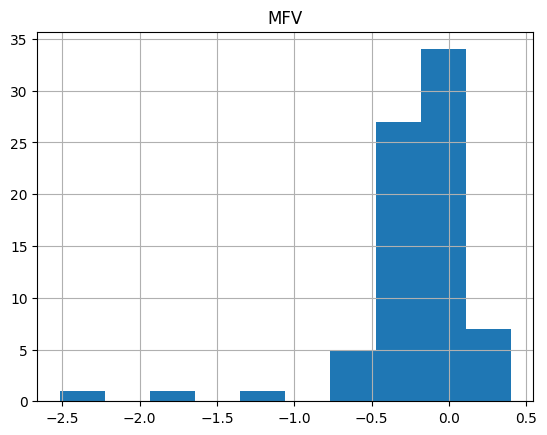

In [178]:
# Daily Return
daily_return = closing_price.pct_change()
# 5-Day Return
ret_5d = closing_price.pct_change(5)
# 10-Day Return
ret_10d = closing_price.pct_change(10)

# 5-Day Volatility (Std Dev of Returns)
vol_5d = closing_price.pct_change().shift(1).rolling(window=5).std()

# 10-Day Volatility
vol_10d = closing_price.pct_change().shift(1).rolling(window=10).std()

# Momentum (10d)
momentum_10d = closing_price - closing_price.shift(10)

AD_momentum_5d = ad_line.pct_change(5)
AD_momentum_10d = ad_line.pct_change(10)
AD_momentum_20d = ad_line.pct_change(20)
# SMA_10/SMA_50 Ratio
sma_10 = closing_price.shift(1).rolling(window=10).mean()
sma_50 = closing_price.shift(1).rolling(window=50).mean()
sma_ratio = sma_10/sma_50

# Z-score (20d)
rolling_mean = closing_price.shift(1).rolling(window=20).mean()
rolling_std = closing_price.shift(1).rolling(window=20).std()
z_score_20d = (closing_price - rolling_mean)/rolling_std

# RSI (14d)
delta = closing_price.diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)

avg_gain = gain.shift(1).rolling(window=14).mean()
avg_loss = loss.shift(1).rolling(window=14).mean()

rs = avg_gain/avg_loss
rsi_14 = 100 - (100 / (1 + rs))

y = closing_price.pct_change(-30)

avrg = y.mean()

y.columns = ['y']


dataframes = [
    (daily_return, 'ret_1d'),
    (ret_5d, 'ret_5d'),
    (ret_10d, 'ret_10d'),
    (vol_5d, 'vol_5d'),
    (vol_10d, 'vol_10d'),
    (momentum_10d, 'momentum_10d'),
    (sma_ratio, 'sma_ratio_10_50'),
    (z_score_20d, 'zscore_20d'),
    (rsi_14, 'rsi_14'),
    (volume,'volume'),
    (AD_momentum_5d,'AD_momentum_5d'),
    (AD_momentum_10d,'AD_momentum_10d'),
    (AD_momentum_20d,'AD_momentum_20d'),
    (y,'y'),
]
AD_momentum_5d.hist()
df_features_short_term = pd.concat(
    [df.rename(columns={df.columns[0]: name}) for df, name in dataframes],
    axis=1
).dropna()

print(df_features_short_term)


In [179]:
from sklearn.metrics import root_mean_squared_error 

X_data = df_features_short_term.drop(columns=['y'])
y = df_features_short_term['y']

with open("scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

# Use loaded scaler to transform new data
X_scaled = loaded_scaler.transform(X_data)

X = pd.DataFrame(X_scaled, index=X_data.index, columns=X_data.columns)

y_pred = loaded_model.predict(X_scaled)
pd.set_option('display.max_rows', None)
result = pd.DataFrame()
result['y'] = y
result['y_pred'] = y_pred
result['diff'] = abs((y-y_pred))
result['sign'] = np.sign(result['y']) == np.sign(result['y_pred'])
result['abs_diff'] = abs(y-y_pred)
result['2diff'] = abs(y-y_pred)<0.09
result = result.replace([np.inf, -np.inf], np.nan)
print(result)
re_sign = (result['2diff']).sum()
same_sign = (result['sign']).sum()
print("mean_abs_err",result['diff'].mean())
print("dirr_acc",same_sign/len(y_pred))
print("rmse",root_mean_squared_error(y_pred, y))


                   y    y_pred      diff  sign  abs_diff  2diff
date                                                           
2023-04-19 -0.069188 -0.013422  0.055765  True  0.055765   True
mean_abs_err 0.05576514669233912
dirr_acc 1.0
rmse 0.05576514669233912
